# 3. Exploratory Data Analysis

This section explores employee demographics, job characteristics, satisfaction, workload, work-life balance, and attrition patterns to identify important trends and relationships in the dataset.

In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load cleaned dataset

df = pd.read_csv("../data/processed/employee_engagement_dataset.csv")

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2


In [3]:
# Check dataset shape

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 1470
Columns: 31


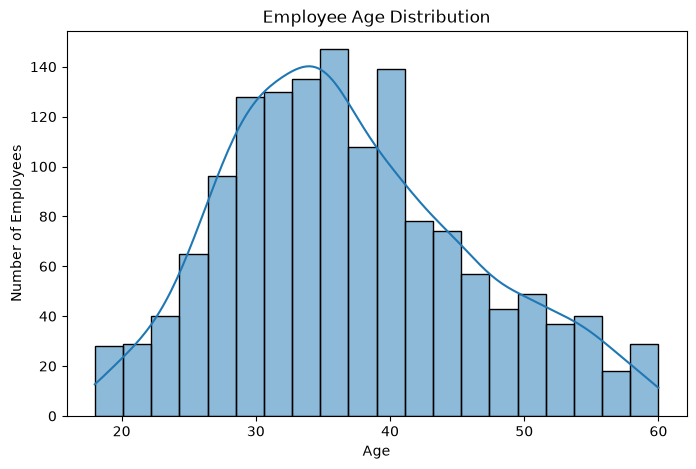

In [4]:
# Analyze employee age distribution

plt.figure(figsize=(8, 5))

sns.histplot(df["Age"], bins=20, kde=True)

plt.title("Employee Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Employees")
plt.show()

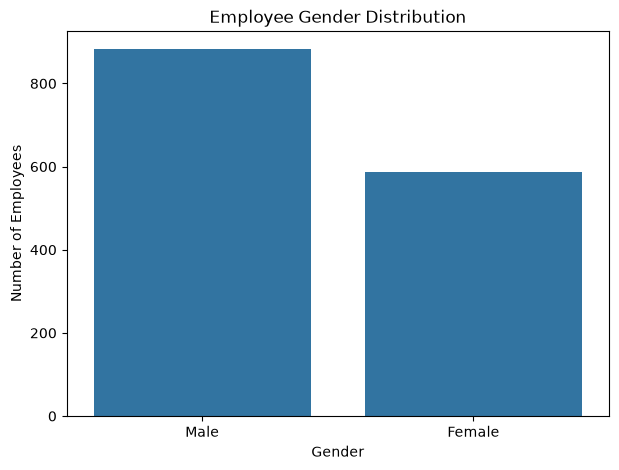

In [5]:
# Analyze gender distribution

gender_counts = df["Gender"].value_counts()

plt.figure(figsize=(7, 5))

sns.barplot(x=gender_counts.index, y=gender_counts.values)

plt.title("Employee Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Employees")
plt.show()

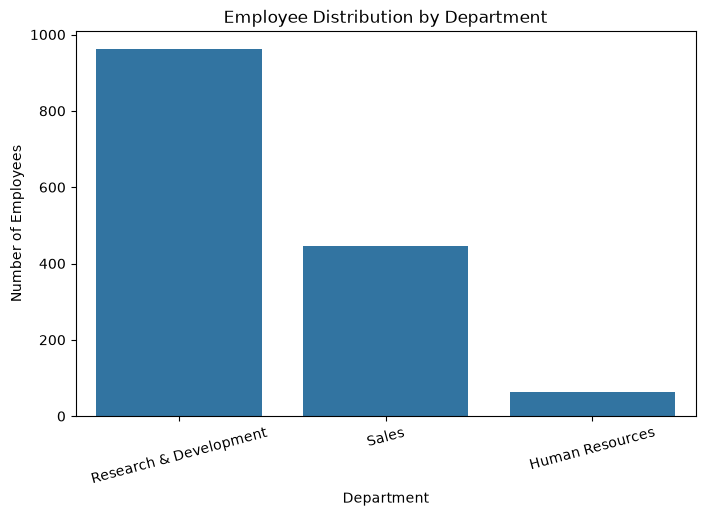

In [6]:
# Analyze department distribution

department_counts = df["Department"].value_counts()

plt.figure(figsize=(8, 5))

sns.barplot(
    x=department_counts.index,
    y=department_counts.values
)

plt.title("Employee Distribution by Department")
plt.xlabel("Department")
plt.ylabel("Number of Employees")
plt.xticks(rotation=15)
plt.show()

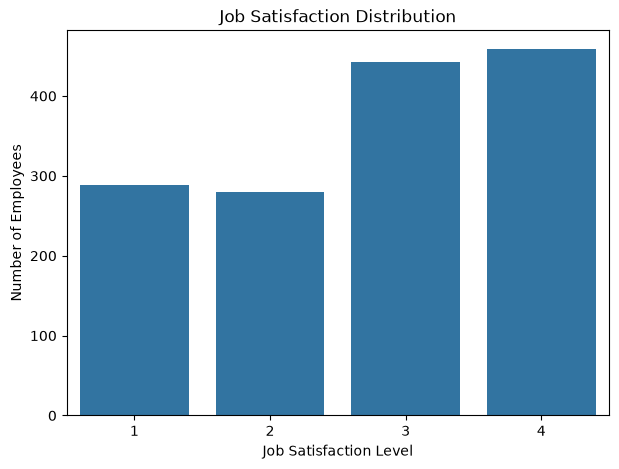

In [7]:
# Analyze job satisfaction distribution

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="JobSatisfaction"
)

plt.title("Job Satisfaction Distribution")
plt.xlabel("Job Satisfaction Level")
plt.ylabel("Number of Employees")
plt.show()

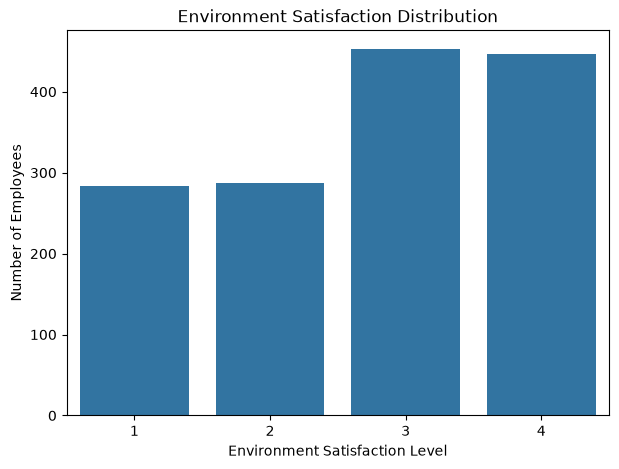

In [8]:
# Analyze environment satisfaction

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="EnvironmentSatisfaction"
)

plt.title("Environment Satisfaction Distribution")
plt.xlabel("Environment Satisfaction Level")
plt.ylabel("Number of Employees")
plt.show()

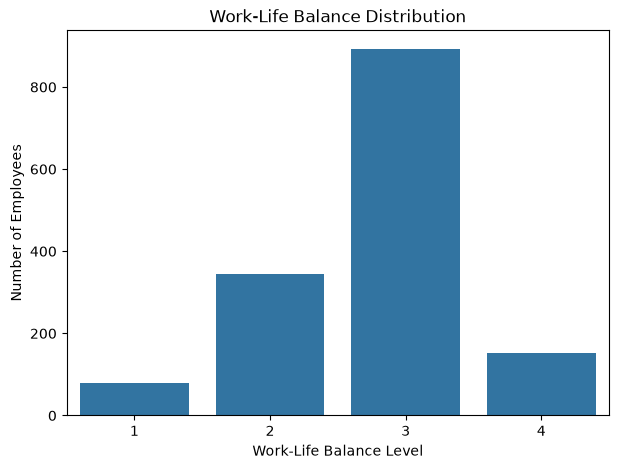

In [9]:
# Analyze work-life balance

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="WorkLifeBalance"
)

plt.title("Work-Life Balance Distribution")
plt.xlabel("Work-Life Balance Level")
plt.ylabel("Number of Employees")
plt.show()

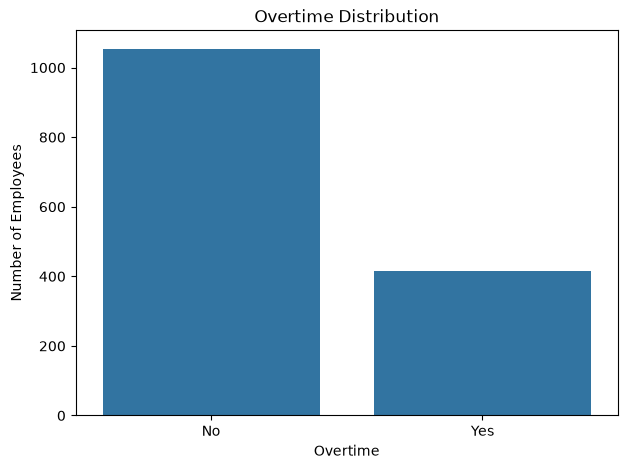

In [10]:
# Analyze overtime distribution

overtime_counts = df["OverTime"].value_counts()

plt.figure(figsize=(7, 5))

sns.barplot(
    x=overtime_counts.index,
    y=overtime_counts.values
)

plt.title("Overtime Distribution")
plt.xlabel("Overtime")
plt.ylabel("Number of Employees")
plt.show()

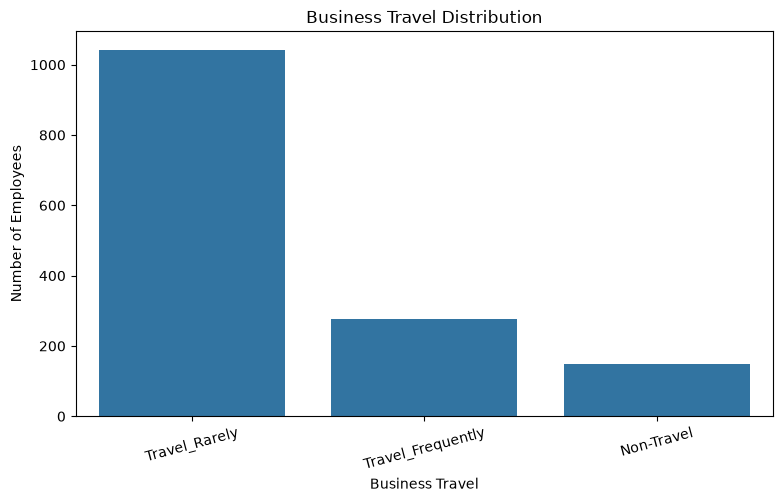

In [11]:
# Analyze business travel frequency

travel_counts = df["BusinessTravel"].value_counts()

plt.figure(figsize=(9, 5))

sns.barplot(
    x=travel_counts.index,
    y=travel_counts.values
)

plt.title("Business Travel Distribution")
plt.xlabel("Business Travel")
plt.ylabel("Number of Employees")
plt.xticks(rotation=15)
plt.show()

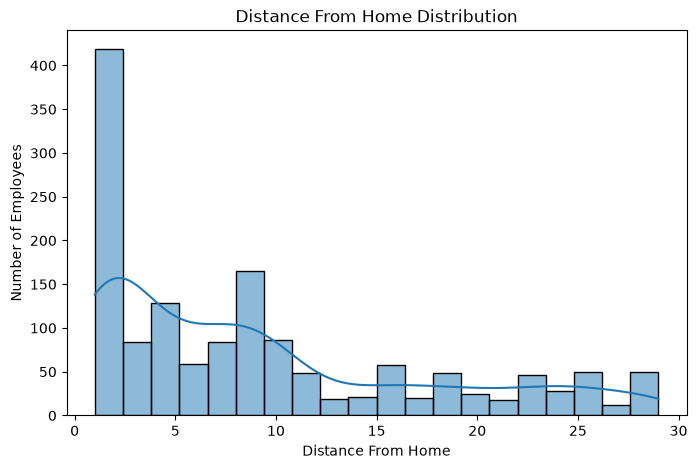

In [12]:
# Analyze employee commute distance

plt.figure(figsize=(8, 5))

sns.histplot(
    df["DistanceFromHome"],
    bins=20,
    kde=True
)

plt.title("Distance From Home Distribution")
plt.xlabel("Distance From Home")
plt.ylabel("Number of Employees")
plt.show()

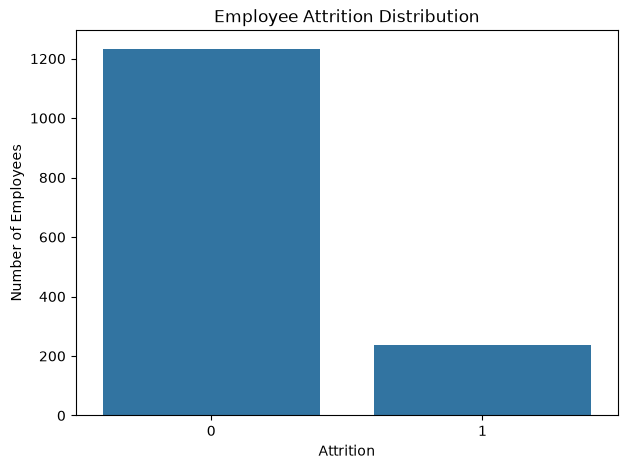

In [13]:
# Analyze attrition distribution

attrition_counts = df["Attrition"].value_counts()

plt.figure(figsize=(7, 5))

sns.barplot(
    x=attrition_counts.index,
    y=attrition_counts.values
)

plt.title("Employee Attrition Distribution")
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")
plt.show()

In [14]:
# Calculate attrition percentage

attrition_percentage = (
    df["Attrition"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(attrition_percentage)

Attrition
0    83.88
1    16.12
Name: proportion, dtype: float64


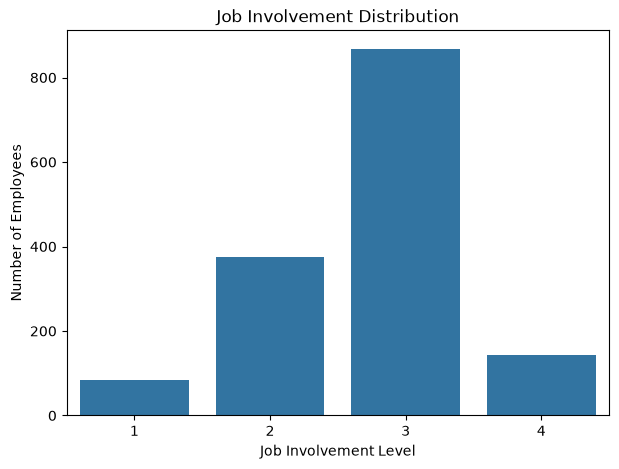

In [15]:
# Analyze job involvement

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="JobInvolvement"
)

plt.title("Job Involvement Distribution")
plt.xlabel("Job Involvement Level")
plt.ylabel("Number of Employees")
plt.show()

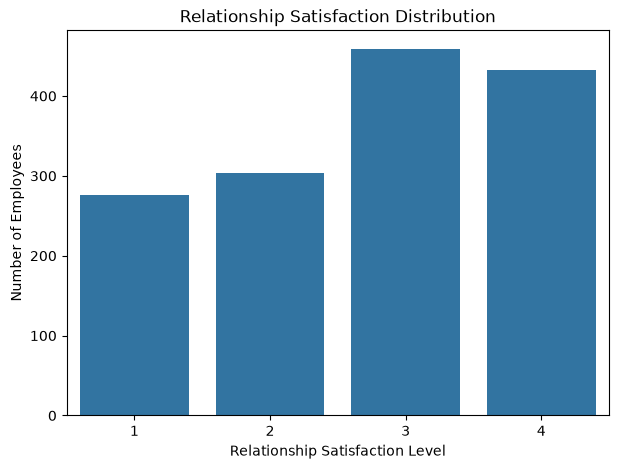

In [16]:
# Analyze relationship satisfaction

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="RelationshipSatisfaction"
)

plt.title("Relationship Satisfaction Distribution")
plt.xlabel("Relationship Satisfaction Level")
plt.ylabel("Number of Employees")
plt.show()

In [17]:
# Compare overtime and work-life balance

overtime_wlb = pd.crosstab(
    df["OverTime"],
    df["WorkLifeBalance"],
    normalize="index"
) * 100

overtime_wlb

WorkLifeBalance,1,2,3,4
OverTime,,,,
No,5.502846,22.770398,60.626186,11.100569
Yes,5.288462,25.000000,61.057692,8.653846


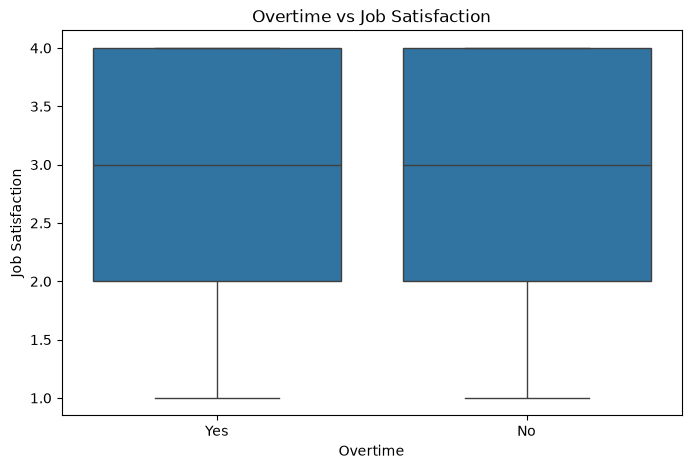

In [18]:
# Compare overtime and job satisfaction

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="OverTime",
    y="JobSatisfaction"
)

plt.title("Overtime vs Job Satisfaction")
plt.xlabel("Overtime")
plt.ylabel("Job Satisfaction")
plt.show()

In [19]:
# Compare business travel and work-life balance

travel_wlb = df.groupby(
    "BusinessTravel"
)["WorkLifeBalance"].mean().sort_values()

print(travel_wlb)

BusinessTravel
Travel_Rarely        2.755513
Non-Travel           2.773333
Travel_Frequently    2.776173
Name: WorkLifeBalance, dtype: float64


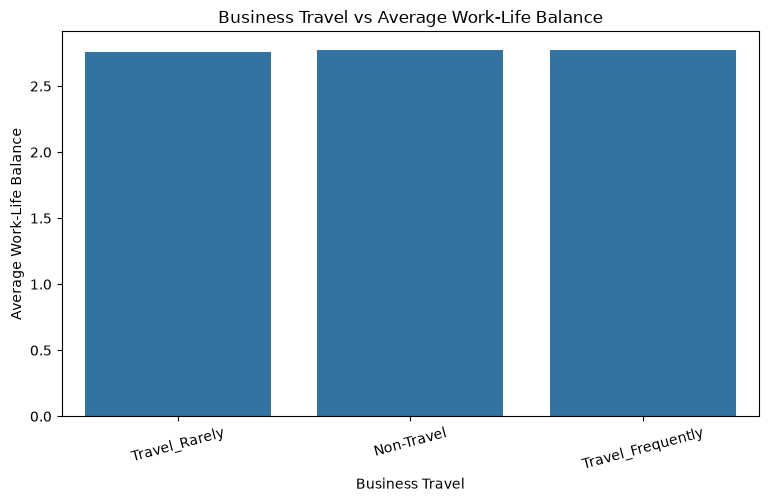

In [20]:
plt.figure(figsize=(9, 5))

sns.barplot(
    x=travel_wlb.index,
    y=travel_wlb.values
)

plt.title("Business Travel vs Average Work-Life Balance")
plt.xlabel("Business Travel")
plt.ylabel("Average Work-Life Balance")
plt.xticks(rotation=15)
plt.show()

In [21]:
# Analyze job level and job satisfaction

joblevel_satisfaction = df.groupby(
    "JobLevel"
)["JobSatisfaction"].mean()

print(joblevel_satisfaction)

JobLevel
1    2.718232
2    2.758427
3    2.678899
4    2.726415
5    2.739130
Name: JobSatisfaction, dtype: float64


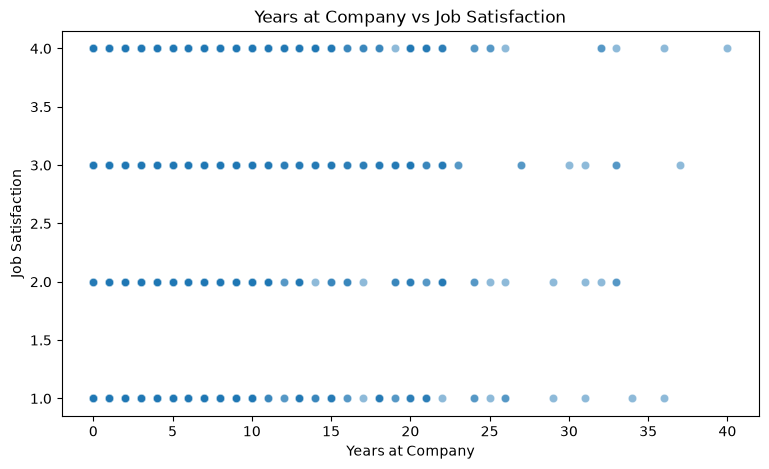

In [22]:
# Analyze tenure and job satisfaction

plt.figure(figsize=(9, 5))

sns.scatterplot(
    data=df,
    x="YearsAtCompany",
    y="JobSatisfaction",
    alpha=0.5
)

plt.title("Years at Company vs Job Satisfaction")
plt.xlabel("Years at Company")
plt.ylabel("Job Satisfaction")
plt.show()

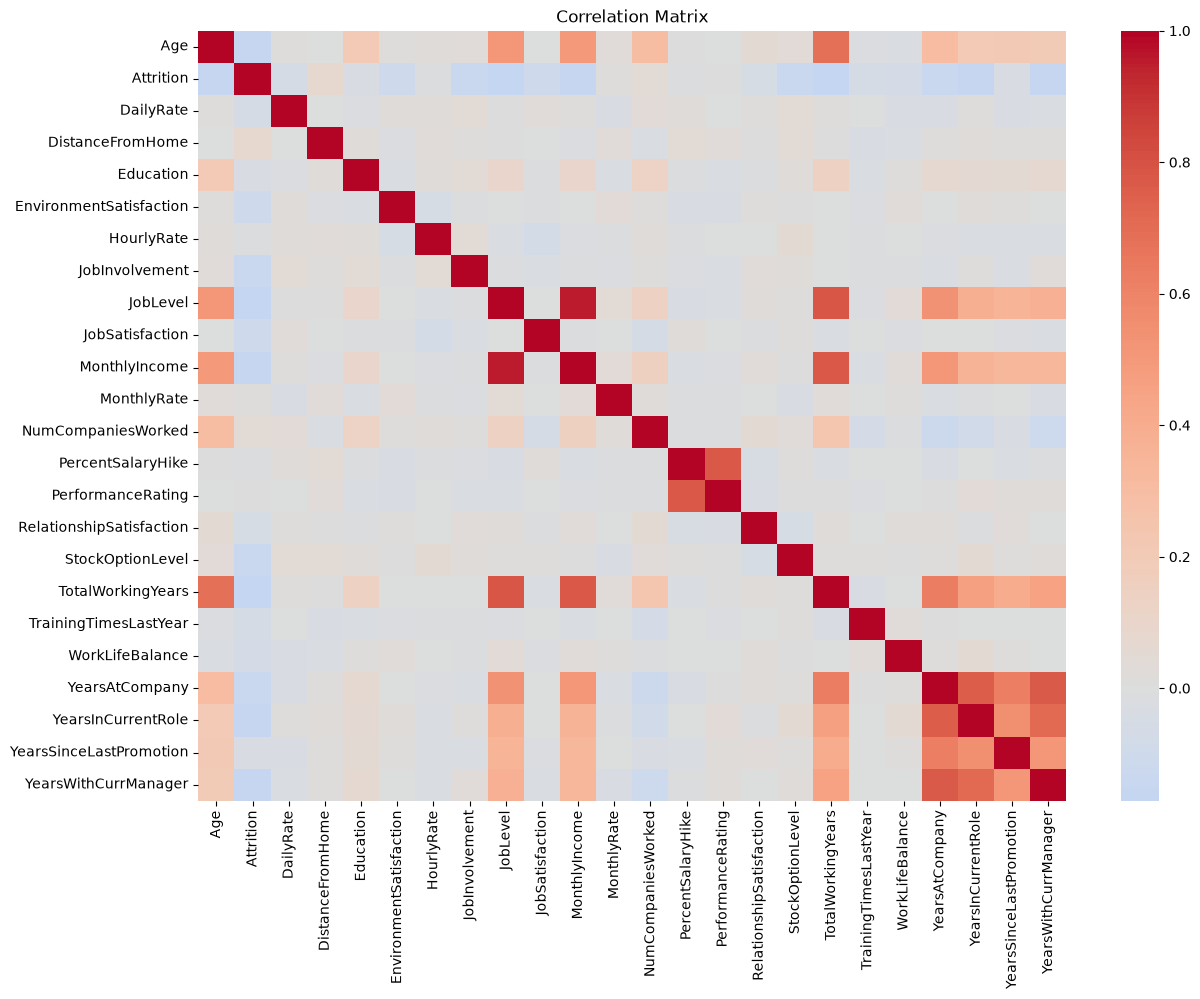

In [23]:
# Analyze correlations between numerical variables

plt.figure(figsize=(14, 10))

correlation_matrix = df.select_dtypes(
    include=np.number
).corr()

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")
plt.show()

In [24]:
# Display correlations among key engagement variables

engagement_columns = [
    "JobInvolvement",
    "JobSatisfaction",
    "EnvironmentSatisfaction",
    "RelationshipSatisfaction",
    "WorkLifeBalance"
]

df[engagement_columns].corr()

,JobInvolvement,JobSatisfaction,EnvironmentSatisfaction,RelationshipSatisfaction,WorkLifeBalance
JobInvolvement,1.000000,-0.021476,-0.008278,0.034297,-0.014617
JobSatisfaction,-0.021476,1.000000,-0.006784,-0.012454,-0.019459
EnvironmentSatisfaction,-0.008278,-0.006784,1.000000,0.007665,0.027627
RelationshipSatisfaction,0.034297,-0.012454,0.007665,1.000000,0.019604
WorkLifeBalance,-0.014617,-0.019459,0.027627,0.019604,1.000000


In [25]:
# Calculate department-wise satisfaction metrics

department_analysis = df.groupby("Department").agg(
    Average_Job_Satisfaction=("JobSatisfaction", "mean"),
    Average_Environment_Satisfaction=("EnvironmentSatisfaction", "mean"),
    Average_Job_Involvement=("JobInvolvement", "mean"),
    Average_WorkLife_Balance=("WorkLifeBalance", "mean")
).round(2)

department_analysis

,Average_Job_Satisfaction,Average_Environment_Satisfaction,Average_Job_Involvement,Average_WorkLife_Balance
Department,,,,
Human Resources,2.60,2.68,2.75,2.92
Research & Development,2.73,2.74,2.74,2.73
Sales,2.75,2.68,2.70,2.82


In [26]:
# Calculate role-wise satisfaction metrics

role_analysis = df.groupby("JobRole").agg(
    Average_Job_Satisfaction=("JobSatisfaction", "mean"),
    Average_Environment_Satisfaction=("EnvironmentSatisfaction", "mean"),
    Average_Job_Involvement=("JobInvolvement", "mean"),
    Average_WorkLife_Balance=("WorkLifeBalance", "mean")
).round(2)

role_analysis

,Average_Job_Satisfaction,Average_Environment_Satisfaction,Average_Job_Involvement,Average_WorkLife_Balance
JobRole,,,,
Healthcare Representative,2.79,2.77,2.73,2.70
Human Resources,2.56,2.60,2.71,2.92
Laboratory Technician,2.69,2.72,2.69,2.72
Manager,2.71,2.76,2.77,2.77
Manufacturing Director,2.68,2.92,2.68,2.77
Research Director,2.70,2.50,2.78,2.86
Research Scientist,2.77,2.73,2.80,2.68
Sales Executive,2.75,2.67,2.71,2.80
Sales Representative,2.73,2.73,2.65,2.89


## Observation

The exploratory analysis provides an overview of employee demographics, satisfaction, workload, work-life balance, career stage, and attrition patterns.

The analysis highlights differences across departments, job roles, overtime groups, travel categories, and career stages. These findings will be used as the foundation for constructing the Engagement Index and identifying employee burnout risk.